# Exploratory Data Analysis

This notebook analyzes a pediatric chest X-ray dataset used to build a binary classifier (**Normal** vs. **Pneumonia**). The clinical goal is to support screening workflows in settings with limited radiologist availability, so understanding the data before training is critical.

### Dataset structure
Images live under `data/` in three splits — `train`, `val`, and `test` — each containing `NORMAL` and `PNEUMONIA` subfolders. Labels are inferred from the leaf folder name.

### What we investigate
1. **Class distribution** — Is the dataset balanced? Imbalance affects loss weighting, metrics, and sampling strategy.
2. **Image properties** — Do dimensions, aspect ratios, and color modes require resizing or channel conversion?
3. **Pixel-level patterns** — Do intensity distributions differ between classes in ways a model could exploit?
4. **Interactive viewer** — Manual spot-checking to catch issues automated stats miss.
5. **Data quality** — Duplicates, corrupted files, and outliers that could inflate metrics or destabilize training.

## Setup

We configure paths, constants, and shared helper functions used across all EDA sections. Centralizing these upfront keeps the analysis reproducible and avoids hard-coded paths scattered through the notebook.

In [4]:
from pathlib import Path
import hashlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

# Suppress non-actionable PIL warnings so quality-check output stays readable
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")

# Relative to notebooks/ — keeps the notebook portable across machines
DATA_DIR = Path("../data")
IMAGE_EXTENSIONS = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
CLASSES = ["NORMAL", "PNEUMONIA"]
SPLITS = ["train", "val", "test"]

## 1. Class Distribution

Class imbalance is one of the first things to check because it directly affects model evaluation and training decisions. A classifier that always predicts the majority class can look accurate while failing clinically on the minority class.

We count images at two levels:
- **Per leaf folder** (`train/NORMAL`, `train/PNEUMONIA`, etc.) — reveals split-specific imbalance and whether any split is too small to be useful.
- **Per class** (aggregated across splits) — shows the overall label ratio the model will encounter.

### Build the image catalog

We walk the folder tree once and store every image path with its split, class label, and leaf folder. This catalog becomes the single source of truth for all downstream analysis.

We also define perceptual hashing helpers here because they are reused in the data quality section to detect duplicate and near-duplicate images that could cause data leakage between splits.

In [5]:
def collect_image_paths(data_dir: Path) -> pd.DataFrame:
    """Scan train/val/test folders and return one row per image."""
    records = []
    for split in SPLITS:
        for class_name in CLASSES:
            folder = data_dir / split / class_name
            if not folder.exists():
                continue
            for path in sorted(folder.iterdir()):
                if path.suffix.lower() in IMAGE_EXTENSIONS:
                    records.append(
                        {
                            "path": path,
                            "split": split,
                            "class": class_name,
                            "leaf_folder": f"{split}/{class_name}",
                        }
                    )
    return pd.DataFrame(records)


def average_hash(img: Image.Image, hash_size: int = 8) -> str:
    """Compute a simple perceptual hash for near-duplicate detection.

    Resizing to 8x8 discards fine detail so visually similar X-rays
    (e.g., re-saved copies) still produce comparable hashes.
    """
    gray = img.convert("L").resize((hash_size, hash_size), Image.LANCZOS)
    pixels = np.asarray(gray, dtype=np.float32)
    avg = pixels.mean()
    return "".join("1" if p > avg else "0" for p in pixels.flatten())


def hamming_distance(hash_a: str, hash_b: str) -> int:
    """Count differing bits — lower distance means more visually similar images."""
    return sum(c1 != c2 for c1, c2 in zip(hash_a, hash_b))


df = collect_image_paths(DATA_DIR)
print(f"Total images: {len(df):,}")
df.head()

Total images: 5,856


,path,split,class,leaf_folder
0,../data/train/NORMAL/IM-0115-0001.jpeg,train,NORMAL,train/NORMAL
1,../data/train/NORMAL/IM-0117-0001.jpeg,train,NORMAL,train/NORMAL
2,../data/train/NORMAL/IM-0119-0001.jpeg,train,NORMAL,train/NORMAL
3,../data/train/NORMAL/IM-0122-0001.jpeg,train,NORMAL,train/NORMAL
4,../data/train/NORMAL/IM-0125-0001.jpeg,train,NORMAL,train/NORMAL


### Summarize and visualize class counts

Pay attention to:
- **Train vs. val vs. test ratios** — the validation set should be large enough to estimate generalization; an tiny val split makes early stopping and hyperparameter tuning unreliable.
- **Pneumonia skew** — if pneumonia dominates, accuracy alone is misleading; precision/recall and class-weighted loss become important.

Images per leaf folder:


,count
leaf_folder,
train/NORMAL,1341
train/PNEUMONIA,3875
val/NORMAL,8
val/PNEUMONIA,8
test/NORMAL,234
test/PNEUMONIA,390



Images per class:


,count
class,
NORMAL,1583
PNEUMONIA,4273


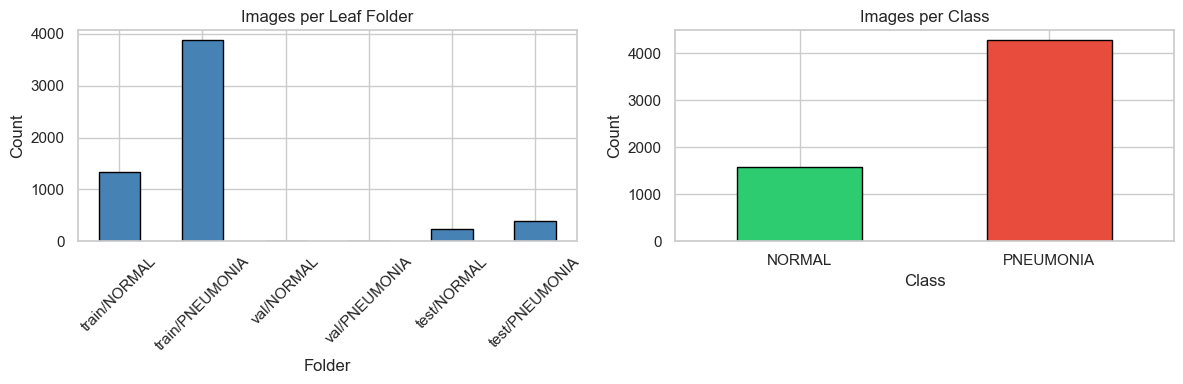

Class balance: NORMAL 27.0% | PNEUMONIA 73.0%


In [6]:
# Fixed ordering ensures bar charts always show train → val → test consistently
leaf_counts = (
    df.groupby("leaf_folder", sort=False)
    .size()
    .reindex([f"{split}/{cls}" for split in SPLITS for cls in CLASSES])
    .dropna()
    .astype(int)
)
class_counts = df.groupby("class").size().reindex(CLASSES)

print("Images per leaf folder:")
display(leaf_counts.to_frame("count"))

print("\nImages per class:")
display(class_counts.to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

leaf_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Images per Leaf Folder")
axes[0].set_xlabel("Folder")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Distinct colors make the two clinical classes immediately distinguishable
class_counts.plot(kind="bar", ax=axes[1], color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[1].set_title("Images per Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

class_pct = (class_counts / class_counts.sum() * 100).round(1)
print(f"Class balance: NORMAL {class_pct['NORMAL']}% | PNEUMONIA {class_pct['PNEUMONIA']}%")

## 2. Image Properties

CNNs expect fixed-size tensor inputs, so we need to understand how much the raw images vary. Wide variation in dimensions implies a resize step in the preprocessing pipeline; wide variation in aspect ratio implies we should consider whether to crop, pad, or distort.

We also verify color mode because chest X-rays are typically **grayscale**. RGB-encoded files would need channel conversion (or would waste model capacity learning redundant channels).

### Extract metadata from every file

Opening each image once here avoids repeated disk I/O in later sections. We also flag unreadable files early so they can be excluded from pixel-level analysis.

In [7]:
def extract_image_metadata(row) -> pd.Series:
    """Read dimensions, color mode, and file size; catch corrupted files gracefully."""
    path = row["path"]
    record = {
        "width": np.nan,
        "height": np.nan,
        "aspect_ratio": np.nan,
        "file_size_kb": path.stat().st_size / 1024,
        "mode": None,
        "readable": False,
        "error": None,
    }
    try:
        with Image.open(path) as img:
            img.load()  # Force decode now so corrupt files are caught here, not later
            record["width"] = img.width
            record["height"] = img.height
            record["aspect_ratio"] = img.width / img.height
            record["mode"] = img.mode
            record["readable"] = True
    except Exception as exc:
        record["error"] = str(exc)
    return pd.Series(record)


meta = df.apply(extract_image_metadata, axis=1)
df = pd.concat([df, meta], axis=1)

print(f"Readable images: {df['readable'].sum():,} / {len(df):,}")
df[["width", "height", "aspect_ratio", "file_size_kb", "mode"]].describe()

Readable images: 5,856 / 5,856


,width,height,aspect_ratio,file_size_kb
count,5856.000000,5856.000000,5856.000000,5856.000000
mean,1327.880806,970.689037,1.442986,206.199238
std,363.500922,383.392117,0.254356,258.600371
min,384.000000,127.000000,0.835391,5.313477
25%,1056.000000,688.000000,1.261627,54.750977
50%,1281.000000,888.000000,1.415885,93.592773
75%,1560.000000,1187.000000,1.585750,230.484619
max,2916.000000,2713.000000,3.378788,2357.755859


### Visualize property distributions

Compare the spread of widths/heights against common CNN input sizes (e.g., 224×224, 256×256). If most images are much larger, downsampling is safe; if they are smaller, upsampling may introduce artifacts.

The number of unique `(width, height)` pairs tells us whether a single resize target is reasonable or whether the dataset contains many distinct acquisition formats.

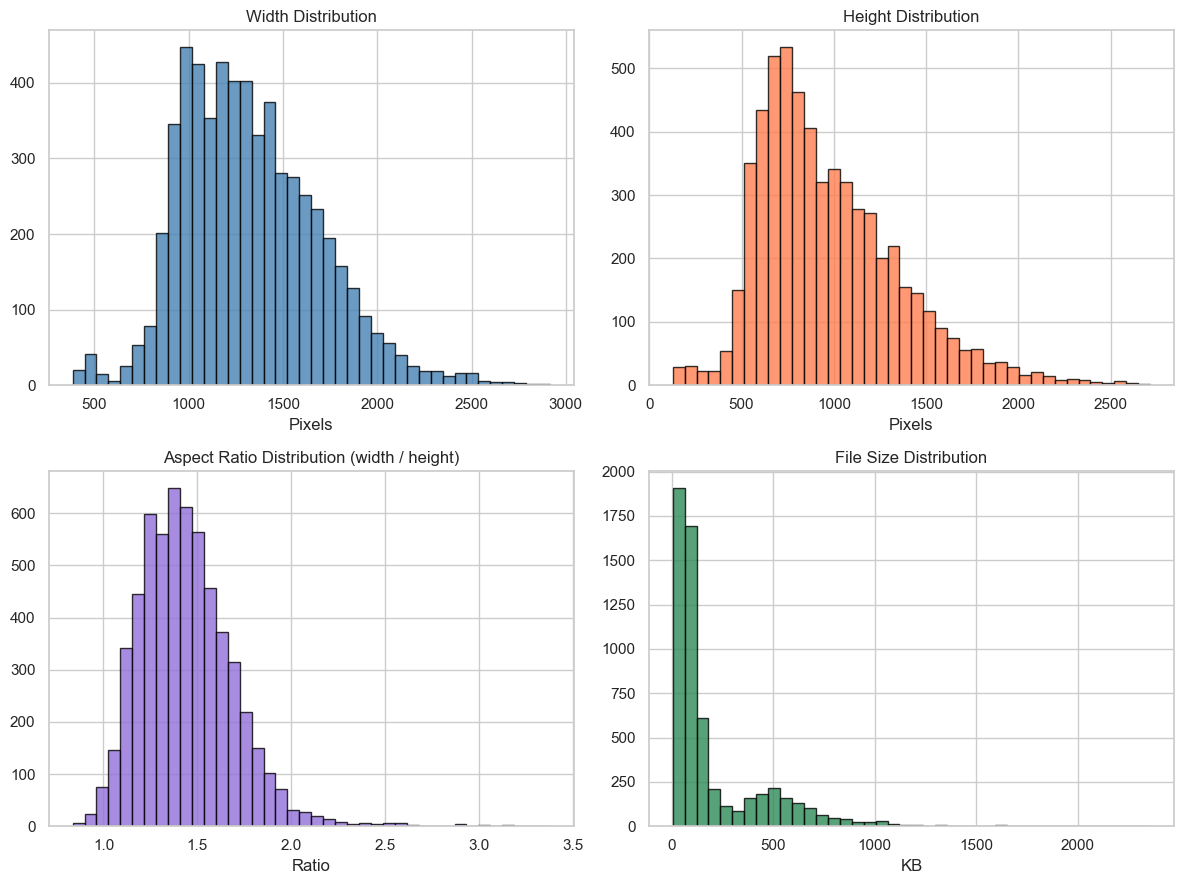

Unique (width, height) pairs: 4803
Top 5 most common dimensions:


,,count
width,height,
1072,648,7
1008,704,7
992,608,6
1216,872,6
1080,728,6



Color mode counts:


,count
mode,
L,5573
RGB,283


Note: Not all images are grayscale (mode 'L'); consider converting to single channel for modeling.

Median dimensions: 1281 x 888
Resizing to a fixed input size (e.g., 224x224) is recommended for CNN training.


In [8]:
# Only analyze images that decoded successfully
readable_df = df[df["readable"]].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(readable_df["width"], bins=40, color="steelblue", edgecolor="black", alpha=0.8)
axes[0, 0].set_title("Width Distribution")
axes[0, 0].set_xlabel("Pixels")

axes[0, 1].hist(readable_df["height"], bins=40, color="coral", edgecolor="black", alpha=0.8)
axes[0, 1].set_title("Height Distribution")
axes[0, 1].set_xlabel("Pixels")

axes[1, 0].hist(readable_df["aspect_ratio"], bins=40, color="mediumpurple", edgecolor="black", alpha=0.8)
axes[1, 0].set_title("Aspect Ratio Distribution (width / height)")
axes[1, 0].set_xlabel("Ratio")

axes[1, 1].hist(readable_df["file_size_kb"], bins=40, color="seagreen", edgecolor="black", alpha=0.8)
axes[1, 1].set_title("File Size Distribution")
axes[1, 1].set_xlabel("KB")

plt.tight_layout()
plt.show()

unique_dims = readable_df.groupby(["width", "height"]).size().sort_values(ascending=False)
print(f"Unique (width, height) pairs: {len(unique_dims)}")
print("Top 5 most common dimensions:")
display(unique_dims.head().to_frame("count"))

mode_counts = readable_df["mode"].value_counts()
print("\nColor mode counts:")
display(mode_counts.to_frame("count"))

if not mode_counts.index.isin(["L"]).all():
    print("Note: Not all images are grayscale (mode 'L'); consider converting to single channel for modeling.")
else:
    print("All readable images are grayscale (mode 'L').")

median_w, median_h = int(readable_df["width"].median()), int(readable_df["height"].median())
print(f"\nMedian dimensions: {median_w} x {median_h}")
print("Resizing to a fixed input size (e.g., 224x224) is recommended for CNN training.")

## 3. Pixel-Level Analysis

Aggregate pixel statistics can reveal class-specific intensity patterns before any model is trained. Pneumonia often presents as brighter opacities in the lung fields, which may shift the overall intensity histogram compared to normal scans.

We compute three complementary views:
- **Per-image mean/std** summarized by class — quick numeric comparison.
- **Overlaid intensity histograms** — shows where the bulk of pixel values fall for each class.
- **Mean composite images** — averages all images in a class (after resizing) to visualize dominant anatomical structure.

### Per-class pixel intensity summary

Converting to grayscale (`L`) before computing stats ensures a single intensity channel, which is what the model will ultimately see after preprocessing.

In [9]:
def compute_pixel_stats(path: Path) -> pd.Series:
    with Image.open(path) as img:
        arr = np.asarray(img.convert("L"), dtype=np.float32)
    return pd.Series({"pixel_mean": arr.mean(), "pixel_std": arr.std()})


pixel_stats = readable_df.apply(lambda row: compute_pixel_stats(row["path"]), axis=1)
readable_df = pd.concat([readable_df, pixel_stats], axis=1)

class_pixel_summary = (
    readable_df.groupby("class")[["pixel_mean", "pixel_std"]]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)
print("Pixel intensity summary by class:")
display(class_pixel_summary)

Pixel intensity summary by class:


pixel_mean                                   pixel_std        \
                 mean        std        min         max      mean   std   
class                                                                     
NORMAL     122.629997  13.540000  73.300003  169.639999     61.27  5.80   
PNEUMONIA  122.839996  19.889999  58.720001  221.539993     55.41  9.96   

                                 
                 min        max  
class                            
NORMAL     33.040001  83.099998  
PNEUMONIA  20.420000  87.480003

### Histograms and mean composite images

All images are resized to a common `COMPOSITE_SIZE` before averaging so that pixel positions align across the dataset. Without this step, the mean image would be a meaningless blur because anatomical features would not line up.

The histogram overlay lets us visually compare whether pneumonia cases tend toward brighter pixel values (right side of the plot), consistent with denser lung opacities.

Pixel analysis:   0%|          | 0/5856 [00:00<?, ?it/s]

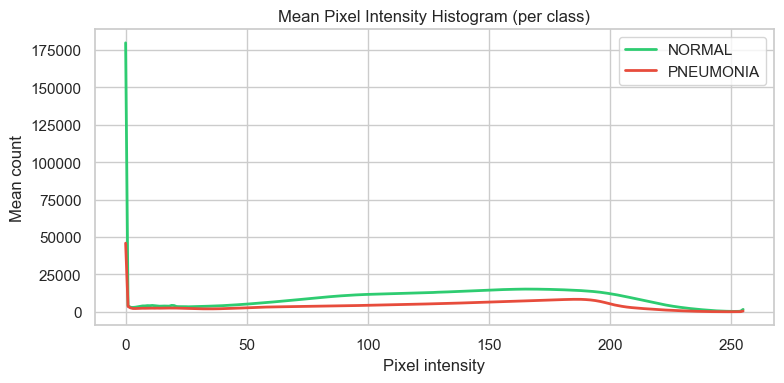

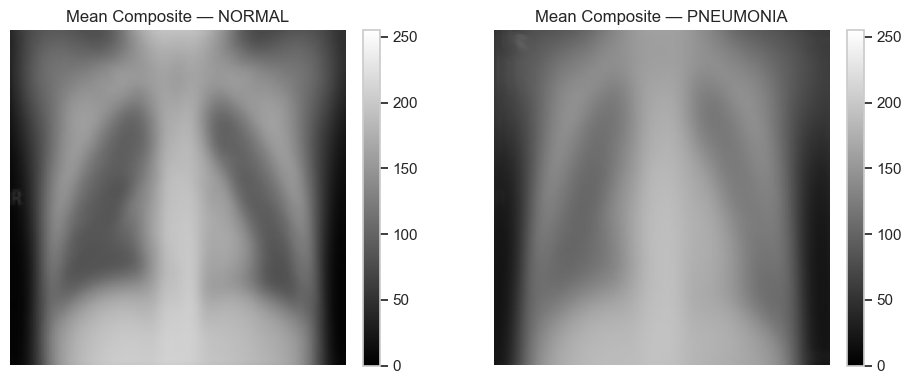

In [10]:
# Small size keeps composite computation fast while preserving coarse lung structure
COMPOSITE_SIZE = (128, 128)
class_hists = {cls: [] for cls in CLASSES}
class_sums = {cls: np.zeros(COMPOSITE_SIZE, dtype=np.float64) for cls in CLASSES}
class_counts_for_composite = {cls: 0 for cls in CLASSES}

for _, row in tqdm(readable_df.iterrows(), total=len(readable_df), desc="Pixel analysis"):
    cls = row["class"]
    with Image.open(row["path"]) as img:
        gray = np.asarray(img.convert("L"), dtype=np.float32)
        resized = np.asarray(
            img.convert("L").resize(COMPOSITE_SIZE, Image.LANCZOS), dtype=np.float64
        )
    class_hists[cls].append(np.histogram(gray, bins=256, range=(0, 256))[0])
    class_sums[cls] += resized
    class_counts_for_composite[cls] += 1

fig, ax = plt.subplots(figsize=(8, 4))
for cls, color in zip(CLASSES, ["#2ecc71", "#e74c3c"]):
    # Average histograms across images rather than pooling all pixels —
    # prevents large images from dominating the class profile
    mean_hist = np.mean(class_hists[cls], axis=0)
    ax.plot(mean_hist, label=cls, color=color, linewidth=2)
ax.set_title("Mean Pixel Intensity Histogram (per class)")
ax.set_xlabel("Pixel intensity")
ax.set_ylabel("Mean count")
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cls in zip(axes, CLASSES):
    mean_img = class_sums[cls] / class_counts_for_composite[cls]
    im = ax.imshow(mean_img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Mean Composite — {cls}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 4. Image Viewer

Automated statistics cannot catch every data issue — mislabeled files, unusual artifacts, or images that don't look like chest X-rays at all. This viewer lets you manually inspect individual images by changing a single index.

The index refers to rows in `readable_df` (images that passed the readability check). Each view shows the image alongside its class, split, dimensions, and pixel statistics.

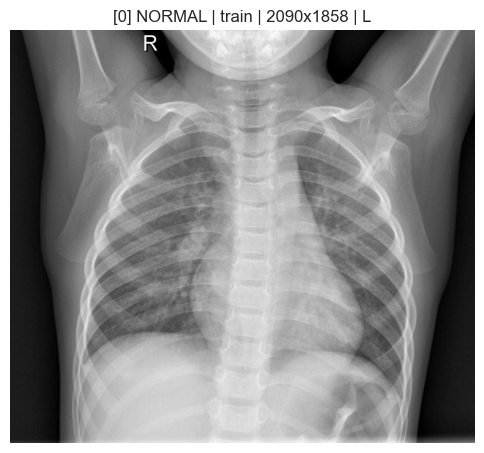

Path: ../data/train/NORMAL/IM-0115-0001.jpeg
File size: 850.4 KB
Pixel mean: 128.91 | Pixel std: 62.30


In [11]:
INDEX = 0  # Change this index to view a different image (0 to len(readable_df)-1)

if not 0 <= INDEX < len(readable_df):
    raise IndexError(f"INDEX must be between 0 and {len(readable_df) - 1}")

row = readable_df.iloc[INDEX]
img = Image.open(row["path"])

fig, ax = plt.subplots(figsize=(6, 6))
# Apply grayscale colormap only when the source is single-channel
ax.imshow(img, cmap="gray" if img.mode == "L" else None)
ax.set_title(
    f"[{INDEX}] {row['class']} | {row['split']} | {row['width']}x{row['height']} | {row['mode']}"
)
ax.axis("off")
plt.show()

print(f"Path: {row['path']}")
print(f"File size: {row['file_size_kb']:.1f} KB")
print(f"Pixel mean: {row['pixel_mean']:.2f} | Pixel std: {row['pixel_std']:.2f}")

## 5. Data Quality Checks

Clean training data is essential for reliable model evaluation. This section looks for:

- **Corrupted files** that would crash the training loop.
- **Exact duplicates** (identical file bytes) that inflate performance metrics.
- **Near-duplicates** (visually similar but not byte-identical) that could leak information between train and test splits.
- **Outliers** in size or intensity that may indicate bad acquisitions or labeling errors.

Duplicates across splits are especially problematic — if the same X-ray appears in both train and test, validation metrics will be optimistically biased.

### Exact duplicates and corrupted files

MD5 hashing compares raw file bytes, catching perfect copies regardless of filename. Perceptual hashing (average hash) catches re-encoded or resized copies that MD5 would miss.

In [12]:
def md5_hash(path: Path) -> str:
    """Hash file contents in chunks to handle large images without loading entirely into memory."""
    hasher = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.hexdigest()


quality_records = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Quality checks"):
    record = {
        "path": row["path"],
        "class": row["class"],
        "split": row["split"],
        "md5": None,
        "avg_hash": None,
    }
    if row["readable"]:
        record["md5"] = md5_hash(row["path"])
        with Image.open(row["path"]) as img:
            record["avg_hash"] = average_hash(img)
    quality_records.append(record)

quality_df = pd.DataFrame(quality_records)

corrupted = df[~df["readable"]]
print(f"Corrupted / unreadable files: {len(corrupted)}")
if len(corrupted):
    display(corrupted[["path", "error"]])

exact_dupes = (
    quality_df.dropna(subset=["md5"])
    .groupby("md5")["path"]
    .apply(list)
    .loc[lambda groups: groups.apply(len) > 1]
)
print(f"\nExact duplicate groups (MD5): {len(exact_dupes)}")
if len(exact_dupes):
    display(exact_dupes.head().to_frame("paths"))

Quality checks:   0%|          | 0/5856 [00:00<?, ?it/s]

Corrupted / unreadable files: 0

Exact duplicate groups (MD5): 30


,paths
md5,
05c43c853e8209bf0423f73a6f0a8c58,[../data/test/NORMAL/NORMAL2-IM-0246-0001-0001...
061c1fac2e79c2d435a6d4c1e35894e7,[../data/train/PNEUMONIA/person1619_bacteria_4...
077fce04eafc798401239d127a84f5f0,[../data/train/PNEUMONIA/person1349_bacteria_3...
23cd1cdafc40ad7f67e6d076ffec52ab,[../data/train/PNEUMONIA/person1481_bacteria_3...
23d698733d4709babc2bf0b40ea67cf4,[../data/train/PNEUMONIA/person357_virus_734.j...


### Near-duplicates and outliers

The near-duplicate scan compares every pair of perceptual hashes and flags pairs with a Hamming distance ≤ `NEAR_DUPE_THRESHOLD`. This is computationally expensive but important — even a handful of cross-split duplicates can noticeably inflate test accuracy.

Size and intensity outliers are flagged using the 1st–99th percentile range. These are not necessarily errors, but they warrant manual review via the image viewer above.

In [13]:
# Hamming distance ≤ 5 is a common threshold for "visually similar" with 64-bit average hashes
NEAR_DUPE_THRESHOLD = 5

perceptual_dupes = (
    quality_df.dropna(subset=["avg_hash"])
    .groupby("avg_hash")["path"]
    .apply(list)
    .loc[lambda groups: groups.apply(len) > 1]
)
print(f"Perceptual duplicate groups (identical average hash): {len(perceptual_dupes)}")
if len(perceptual_dupes):
    display(perceptual_dupes.head().to_frame("paths"))

hash_records = quality_df.dropna(subset=["avg_hash"])[["path", "avg_hash"]].to_records(index=False)
near_dupe_pairs = []
for i in tqdm(range(len(hash_records)), desc="Near-duplicate scan", leave=False):
    path_i, hash_i = hash_records[i]
    for j in range(i + 1, len(hash_records)):
        path_j, hash_j = hash_records[j]
        distance = hamming_distance(hash_i, hash_j)
        # Exclude distance=0 (already caught by identical-hash grouping above)
        if 0 < distance <= NEAR_DUPE_THRESHOLD:
            near_dupe_pairs.append((path_i, path_j, distance))

print(f"Near-duplicate pairs (Hamming distance 1–{NEAR_DUPE_THRESHOLD}): {len(near_dupe_pairs)}")
if near_dupe_pairs:
    display(pd.DataFrame(near_dupe_pairs[:10], columns=["path_a", "path_b", "distance"]))

# Flag images whose dimensions fall in the extreme 2% tails
size_outliers = readable_df[
    (readable_df["width"] < readable_df["width"].quantile(0.01))
    | (readable_df["width"] > readable_df["width"].quantile(0.99))
    | (readable_df["height"] < readable_df["height"].quantile(0.01))
    | (readable_df["height"] > readable_df["height"].quantile(0.99))
]
# Unusually dark or bright scans may indicate acquisition issues or atypical pathology
intensity_outliers = readable_df[
    (readable_df["pixel_mean"] < readable_df["pixel_mean"].quantile(0.01))
    | (readable_df["pixel_mean"] > readable_df["pixel_mean"].quantile(0.99))
]

print(f"\nSize outliers (outside 1st–99th percentile): {len(size_outliers)}")
print(f"Intensity outliers (outside 1st–99th percentile): {len(intensity_outliers)}")

if len(size_outliers):
    display(size_outliers[["path", "class", "split", "width", "height"]].head(10))
if len(intensity_outliers):
    display(intensity_outliers[["path", "class", "split", "pixel_mean", "pixel_std"]].head(10))

Perceptual duplicate groups (identical average hash): 218


,paths
avg_hash,
0000000000001000000111000001111000011110011111100111111001111110,[../data/train/PNEUMONIA/person296_virus_613.j...
0000000000010000000110000001110000011100000111000111111001111110,[../data/train/PNEUMONIA/person554_bacteria_23...
0000011100011110001111000011110001111110011111101111111011111110,[../data/train/PNEUMONIA/person688_virus_1281....
0001100000011000000110000011110000111100001111000111110001111100,[../data/train/PNEUMONIA/person1413_virus_2422...
0001100000011000111111110110101101111111001111100011111000111110,[../data/test/NORMAL/NORMAL2-IM-0095-0001.jpeg...


Near-duplicate scan:   0%|          | 0/5856 [00:00<?, ?it/s]

Near-duplicate pairs (Hamming distance 1–5): 385907


,path_a,path_b,distance
0,../data/train/NORMAL/IM-0115-0001.jpeg,../data/train/NORMAL/IM-0193-0001.jpeg,5
1,../data/train/NORMAL/IM-0115-0001.jpeg,../data/train/NORMAL/IM-0227-0001.jpeg,5
2,../data/train/NORMAL/IM-0115-0001.jpeg,../data/train/NORMAL/IM-0241-0001.jpeg,2
3,../data/train/NORMAL/IM-0115-0001.jpeg,../data/train/NORMAL/IM-0249-0001.jpeg,5
4,../data/train/NORMAL/IM-0115-0001.jpeg,../data/train/NORMAL/IM-0274-0001.jpeg,5
5,../data/train/NORMAL/IM-0115-0001.jpeg,../data/train/NORMAL/IM-0276-0001.jpeg,4
6,../data/train/NORMAL/IM-0115-0001.jpeg,../data/train/NORMAL/IM-0290-0001.jpeg,5
7,../data/train/NORMAL/IM-0115-0001.jpeg,../data/train/NORMAL/IM-0292-0001.jpeg,4
8,../data/train/NORMAL/IM-0115-0001.jpeg,../data/train/NORMAL/IM-0306-0001.jpeg,5
9,../data/train/NORMAL/IM-0115-0001.jpeg,../data/train/NORMAL/IM-0316-0001.jpeg,4



Size outliers (outside 1st–99th percentile): 148
Intensity outliers (outside 1st–99th percentile): 118


,path,class,split,width,height
83,../data/train/NORMAL/IM-0249-0001.jpeg,NORMAL,train,2396,1990
152,../data/train/NORMAL/IM-0335-0001.jpeg,NORMAL,train,2538,1897
212,../data/train/NORMAL/IM-0413-0001.jpeg,NORMAL,train,2318,2411
279,../data/train/NORMAL/IM-0480-0001.jpeg,NORMAL,train,2218,2183
294,../data/train/NORMAL/IM-0493-0001.jpeg,NORMAL,train,2260,2237
330,../data/train/NORMAL/IM-0517-0001.jpeg,NORMAL,train,2844,2067
335,../data/train/NORMAL/IM-0521-0001.jpeg,NORMAL,train,2890,2534
355,../data/train/NORMAL/IM-0533-0001.jpeg,NORMAL,train,2518,2364
392,../data/train/NORMAL/IM-0557-0001.jpeg,NORMAL,train,2442,2226
496,../data/train/NORMAL/IM-0652-0001.jpeg,NORMAL,train,2480,1924


,path,class,split,pixel_mean,pixel_std
837,../data/train/NORMAL/NORMAL2-IM-0707-0001.jpeg,NORMAL,train,168.389587,68.746529
852,../data/train/NORMAL/NORMAL2-IM-0771-0001.jpeg,NORMAL,train,73.297791,38.165253
953,../data/train/NORMAL/NORMAL2-IM-0899-0001.jpeg,NORMAL,train,169.641876,54.563591
1374,../data/train/PNEUMONIA/person101_virus_188.jpeg,PNEUMONIA,train,73.502800,53.429649
1499,../data/train/PNEUMONIA/person108_virus_199.jpeg,PNEUMONIA,train,173.302567,24.263983
1517,../data/train/PNEUMONIA/person1099_virus_1819....,PNEUMONIA,train,171.484467,36.303852
1525,../data/train/PNEUMONIA/person1103_bacteria_30...,PNEUMONIA,train,170.070709,52.835739
1542,../data/train/PNEUMONIA/person1111_bacteria_30...,PNEUMONIA,train,185.187210,31.515318
1670,../data/train/PNEUMONIA/person1176_bacteria_31...,PNEUMONIA,train,166.722931,40.524040
1686,../data/train/PNEUMONIA/person1180_virus_2007....,PNEUMONIA,train,74.699814,37.697063
